# **Предобработка датасета**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,  mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import impute
from sklearn import preprocessing
import numpy as np
import warnings
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from IPython.display import clear_output
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm

In [ ]:
df = pd.read_csv('/content/resultwithfeatures.csv', low_memory=False)
df.head()

,Source,Smiles,Exp. Animal,Method of administration,LD50,LD50 (a.u.),Carcinogenicity,Carcinogenicity (a.u.),Hepatoxicity,Hepatoxicity (a.u.),...,MorganFP_1015,MorganFP_1016,MorganFP_1017,MorganFP_1018,MorganFP_1019,MorganFP_1020,MorganFP_1021,MorganFP_1022,MorganFP_1023,MorganFP_1024
0,ChEMBL,Br.Br.Cc1cc(-c2ccc(O)cc2)nnc1NCCN1CCOCC1,mouse,intraperitoneal,300.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1,ChEMBL,Br.Br.Cc1cc(-c2cccc(O)c2)nnc1NCCN1CCOCC1,mouse,intraperitoneal,200.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
2,ChEMBL,Br.Br.Cc1cc(-c2ccccc2O)nnc1NCCN1CCOCC1,mouse,intraperitoneal,200.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
3,ChEMBL,Br.CC(C)C(N)C(=O)NNc1nncc(-c2ccc(Cl)cc2)n1.O,mouse,intraperitoneal,178.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,1,0
4,ChEMBL,Br.CC(C)N(CCCOc1ccc(N/C(=N\c2ccccc2)c2ccccc2)c...,mouse,intraperitoneal,140.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.describe()

/usr/local/lib/python3.11/dist-packages/pandas/core/nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)


,LD50,Carcinogenicity,Carcinogenicity (a.u.),Hepatoxicity,Hepatoxicity (a.u.),Eye_Corrosion,Eye_Corrosion (a.u.),Eye_Irritation,Eye_Irritation (a.u.),Mutagenicity,...,MorganFP_1015,MorganFP_1016,MorganFP_1017,MorganFP_1018,MorganFP_1019,MorganFP_1020,MorganFP_1021,MorganFP_1022,MorganFP_1023,MorganFP_1024
count,9.921700e+04,1099.000000,0.0,3346.000000,0.0,2627.000000,0.0,5577.000000,0.0,7836.000000,...,114757.000000,114757.000000,114757.000000,114757.000000,114757.000000,114757.000000,114757.000000,114757.000000,114757.000000,114757.000000
mean,1.627611e+03,0.481347,NaN,0.510460,NaN,0.347164,NaN,0.708087,NaN,0.548111,...,0.025367,0.012731,0.006326,0.094068,0.013489,0.277595,0.023380,0.016522,0.017881,0.008287
std,2.196844e+04,0.499879,NaN,0.499965,NaN,0.476159,NaN,0.454683,NaN,0.497712,...,0.157237,0.112113,0.079287,0.291925,0.115358,0.447815,0.151107,0.127472,0.132520,0.090656
min,0.000000e+00,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000e+02,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000e+02,0.000000,NaN,1.000000,NaN,0.000000,NaN,1.000000,NaN,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000033e+03,1.000000,NaN,1.000000,NaN,1.000000,NaN,1.000000,NaN,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,2.500000e+06,1.000000,NaN,1.000000,NaN,1.000000,NaN,1.000000,NaN,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df.columns[:25]

Index(['Source', 'Smiles', 'Exp. Animal', 'Method of administration', 'LD50',
       'LD50 (a.u.)', 'Carcinogenicity', 'Carcinogenicity (a.u.)',
       'Hepatoxicity', 'Hepatoxicity (a.u.)', 'Eye_Corrosion',
       'Eye_Corrosion (a.u.)', 'Eye_Irritation', 'Eye_Irritation (a.u.)',
       'Mutagenicity', 'Mutagenicity (a.u.)', 'Respiratory_Toxicity',
       'Respiratory_Toxicity (a.u.)', 'LC50', 'LC50 (a.u.)', 'NOAEL',
       'NOAEL (a.u)', 'MaxAbsEStateIndex', 'MaxEStateIndex',
       'MinAbsEStateIndex'],
      dtype='object')

In [ ]:
df = df.drop_duplicates(subset = ['Smiles', 'Exp. Animal', 'Method of administration'])
df.shape

(114033, 1422)

In [ ]:
cat_features_mask = (df.dtypes == "object").values

obj_cols = df.select_dtypes('object').columns
df[obj_cols] = df[obj_cols].astype('category')

In [ ]:
df.memory_usage(deep=True).sum() / 1024

np.float64(1273943.888671875)

In [ ]:
fcols = df.select_dtypes('float').columns
icols = df.select_dtypes('integer').columns

df[fcols] = df[fcols].apply(pd.to_numeric, downcast='float')
df[icols] = df[icols].apply(pd.to_numeric, downcast='integer')

In [ ]:
df = df.drop(['Source', 'Smiles',
       'LD50 (a.u.)', 'Carcinogenicity', 'Carcinogenicity (a.u.)',
       'Hepatoxicity', 'Hepatoxicity (a.u.)', 'Eye_Corrosion',
       'Eye_Corrosion (a.u.)', 'Eye_Irritation', 'Eye_Irritation (a.u.)',
       'Mutagenicity', 'Mutagenicity (a.u.)', 'Respiratory_Toxicity',
       'Respiratory_Toxicity (a.u.)', 'LC50', 'LC50 (a.u.)', 'NOAEL',
       'NOAEL (a.u)'], axis = 1).reset_index(drop = True)
df = df.dropna(subset=['LD50'])

In [ ]:
threshold = 0.996

def drop_constant_columns(df, threshold):
    to_drop = []  # Список столбцов для удаления
    for col in df.columns:
        max_freq = df[col].value_counts(normalize=True).max()
        if max_freq >= threshold:
            to_drop.append(col)
    # Удаляем столбцы
    return df.drop(columns=to_drop)

# Применяем функцию
df_cleaned = drop_constant_columns(df, threshold)
print(f'Размер датасета после чистки {df_cleaned.shape}')

Размер датасета после чистки (98512, 1383)


In [ ]:
df = df_cleaned
df = df[df['LD50']>0].copy() #если случайно пропущены 0 значения

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df['lof_outlier'] = lof.fit_predict(df[['LD50']])

df = df[df['lof_outlier'] == 1]
df.drop(columns=['lof_outlier'], inplace=True)
df.shape

/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
<ipython-input-43-5d517239ddfe>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['lof_outlier'], inplace=True)


(93581, 1383)

In [ ]:
df = df.dropna()
df.shape

(90141, 1383)

In [ ]:
df['log_LD50'] = np.log1p(df['LD50'])

Смещение распределения

<Axes: >

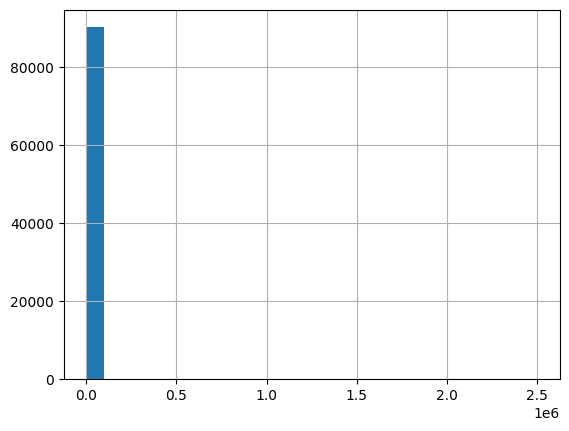

In [ ]:
df['LD50'].hist(bins=25)

<Axes: >

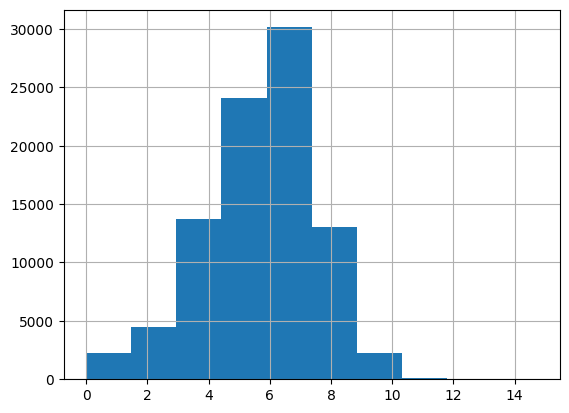

In [ ]:
df['log_LD50'].hist()

In [ ]:
X = df.drop(columns=['LD50', 'log_LD50'])
y = df['log_LD50']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=True, random_state=123)

In [ ]:
num_col = X.select_dtypes(include=['number']).columns.tolist()
cat_col = X.select_dtypes(include=['category']).columns.tolist()

X_train_cat = X_train[cat_col]
X_train_num = X_train[num_col]

X_test_cat = X_test[cat_col]
X_test_num = X_test[num_col]

In [ ]:
OHE = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop = 'first')  # handle_unknown='ignore' для новых категорий в тесте

X_train_encoded = OHE.fit_transform(X_train_cat)
X_test_encoded = OHE.transform(X_test_cat)

ohe_columns = OHE.get_feature_names_out(cat_col)
X_train_cat = pd.DataFrame(X_train_encoded, columns=ohe_columns, index=X_train.index)
X_test_cat = pd.DataFrame(X_test_encoded, columns=ohe_columns, index=X_test.index)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train[num_col])
X_test_scaled = scaler.transform(X_test[num_col])

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col, index=X_test.index)

In [ ]:
X_train = pd.concat([X_train_cat, X_train_scaled], axis=1)
X_test = pd.concat([X_test_cat, X_test_scaled], axis=1)

In [ ]:
X_train.shape

(67605, 1392)

# **Полносвязная нейросеть**

План работ:


1.   Написание функции для обучения NN и валидации
2.   Обозначение первой сетки с 3 слоями, без дополнительных накруток
2.   Проведение экспериментов на базе первой сетки:

    *   Изменение функций активации
    *   Изменение глубины сетки и ее параметров
    *   Изменение архитектуры (Batchnorm, Dropout)

Метрика MAPE не умножена на 100 при вычисляениях, а взята из прямых библиотечных расчетов, то есть выражена не в %, а в долях




In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

In [ ]:
random_state = 123

Обучение и оценку качества будем проводить на данных трейн и валидации

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=random_state
)
X_train.shape, X_val.shape

((50703, 1392), (16902, 1392))

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")

Заготовка функции для обучения, валидации и теста

In [ ]:
import torch
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error, r2_score

from tqdm import tqdm

def test(model, loader):
    loss_log = []
    mape_log = []
    r2_log = []
    model.eval()
    with torch.no_grad():
        pbar = tqdm(loader, desc="Valid", leave=False)
        for data, target in pbar:
            data, target = data.to(device), target.to(device)
            y_pred = model(data).squeeze(-1)

            loss = torch.nn.functional.mse_loss(y_pred, target)
            loss_log.append(loss.item())

            y_true_exp = torch.expm1(target).detach().cpu().numpy()
            y_pred_exp = torch.expm1(y_pred).detach().cpu().numpy()

            mape = mean_absolute_percentage_error(y_true_exp, y_pred_exp)
            r2 = r2_score(y_true_exp, y_pred_exp)

            mape_log.append(mape)
            r2_log.append(r2)

            pbar.set_postfix({"loss": loss.item(), "mape": mape, "r2": r2})

    return np.mean(loss_log), np.mean(mape_log), np.mean(r2_log)


def train_epoch(model, optimizer, criterion, train_loader):
    loss_log = []
    mape_log = []
    r2_log = []
    model.train()

    pbar = tqdm(train_loader, desc="Train", leave=False)
    for data, target in pbar:
        data, target = data.to(device), target.to(device)
        y_pred = model(data).squeeze(-1)

        loss = criterion(y_pred, target)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_log.append(loss.item())

        y_true_exp = torch.expm1(target).detach().cpu().numpy()
        y_pred_exp = torch.expm1(y_pred).detach().cpu().numpy()

        mape = mean_absolute_percentage_error(y_true_exp, y_pred_exp)
        r2 = r2_score(y_true_exp, y_pred_exp)

        mape_log.append(mape)
        r2_log.append(r2)

        pbar.set_postfix({"loss": loss.item(), "mape": mape, "r2": r2})

    return loss_log, mape_log, r2_log



def train(model, optimizer, criterion, n_epochs, train_loader, val_loader, scheduler=None):
    train_loss_log, train_mape_log, train_r2_log = [], [], []
    val_loss_log, val_mape_log, val_r2_log = [], [], []

    for epoch in range(n_epochs):
        train_loss, train_mape, train_r2 = train_epoch(model, optimizer,criterion, train_loader)
        val_loss, val_mape, val_r2 = test(model, val_loader)

        train_loss_log.extend(train_loss)
        train_mape_log.extend(train_mape)
        train_r2_log.extend(train_r2)

        val_loss_log.append(val_loss)
        val_mape_log.append(val_mape)
        val_r2_log.append(val_r2)

        print(f"Epoch {epoch}")
        print(f" train loss: {np.mean(train_loss):.4f}, train MAPE: {np.mean(train_mape):.2f}, train R2: {np.mean(train_r2):.4f}")
        print(f" val loss: {val_loss:.4f}, val MAPE: {val_mape:.2f}, val R2: {val_r2:.4f}\n")

        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

    return train_loss_log, train_mape_log, train_r2_log, val_loss_log, val_mape_log, val_r2_log

In [ ]:
from torch.utils.data import Dataset
class Dataset_toxic(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return torch.tensor(self.x.iloc[idx].values, dtype=torch.float32), torch.tensor(self.y.iloc[idx], dtype=torch.float32)

In [ ]:
train_dataset = Dataset_toxic(X_train, y_train)
val_dataset = Dataset_toxic(X_val, y_val)
test_dataset = Dataset_toxic(X_test, y_test)

train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=64, shuffle=True, num_workers=2
)
val_dataloader = torch.utils.data.DataLoader(
    val_dataset, batch_size=64, shuffle=True, num_workers=2
)
test_dataloader = torch.utils.data.DataLoader(
    test_dataset, batch_size=64, shuffle=True, num_workers=2
)

In [ ]:
import torch
import torch.nn as nn

class SimpleRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(X_train.shape[1], 256)
        self.batchnorm1 = nn.BatchNorm1d(256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.batchnorm2 = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128, 1)
        self.dropout = nn.Dropout()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.fc1(x)
        out = self.batchnorm1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.batchnorm2(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc3(out)
        return out

**Применение оптимизатора - SGD**

In [ ]:
model_regress = SimpleRegressor()
model_regress

SimpleRegressor(
  (fc1): Linear(in_features=1392, out_features=256, bias=True)
  (batchnorm1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (batchnorm2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

In [ ]:
train_loss_log, train_mape_log, train_r2_log, val_loss_log, val_mape_log, val_r2_log = train(
    model = model_regress,
    optimizer=torch.optim.SGD(model_regress.parameters(), lr=1e-2),
    criterion=torch.nn.functional.mse_loss,
    n_epochs = 10,
    train_loader=train_dataloader,
    val_loader=val_dataloader
)

Epoch 0
 train loss: 2.7239, train MAPE: 66.99, train R2: -2.9847
 val loss: 1.9535, val MAPE: 14.91, val R2: 0.1169



Epoch 1
 train loss: 2.0249, train MAPE: 42.56, train R2: -0.5972
 val loss: 2.1032, val MAPE: 10.70, val R2: 0.0229



Epoch 2
 train loss: 1.8173, train MAPE: 44.21, train R2: -0.7304
 val loss: 2.5193, val MAPE: 9.90, val R2: -0.0922



Epoch 3
 train loss: 1.7261, train MAPE: 35.21, train R2: -0.4080
 val loss: 1.6450, val MAPE: 14.26, val R2: 0.1783



Epoch 4
 train loss: 1.6612, train MAPE: 33.01, train R2: -0.4759
 val loss: 1.8635, val MAPE: 11.36, val R2: 0.0614



Epoch 5
 train loss: 1.6187, train MAPE: 34.54, train R2: -0.6593
 val loss: 2.0968, val MAPE: 10.42, val R2: 0.0103



Epoch 6
 train loss: 1.5823, train MAPE: 27.64, train R2: -0.2802
 val loss: 1.5297, val MAPE: 12.14, val R2: 0.2328



Epoch 7
 train loss: 1.5478, train MAPE: 29.64, train R2: -0.3802
 val loss: 1.4213, val MAPE: 13.09, val R2: 0.1296



Epoch 8
 train loss: 1.5160, train MAPE: 26.56, train R2: -0.4079
 val loss: 1.5793, val MAPE: 11.14, val R2: 0.1362



Epoch 9
 train loss: 1.4736, train MAPE: 24.60, train R2: -0.2836
 val loss: 1.3999, val MAPE: 11.53, val R2: 0.2575



In [ ]:
loss_log, mape_log, r2_log = test(model_regress, test_dataloader)

print(f'MAPE на тесте: {mape_log}')

MAPE на тесте: 23.461846341323582


**Функция потерь - Smooth1Loss**

In [ ]:
model_regress = SimpleRegressor()
model_regress

SimpleRegressor(
  (fc1): Linear(in_features=1392, out_features=256, bias=True)
  (batchnorm1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (batchnorm2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

In [ ]:
train_loss_log, train_mape_log, train_r2_log, val_loss_log, val_mape_log, val_r2_log = train(
    model = model_regress,
    optimizer=torch.optim.SGD(model_regress.parameters(), lr=1e-2),
    criterion=nn.SmoothL1Loss(),
    n_epochs = 10,
    train_loader=train_dataloader,
    val_loader=val_dataloader
)

Epoch 0
 train loss: 1.0028, train MAPE: 111.73, train R2: -6.1923
 val loss: 4.6818, val MAPE: 5.76, val R2: -0.1926



Epoch 1
 train loss: 0.7885, train MAPE: 63.96, train R2: -5.7399
 val loss: 3.3282, val MAPE: 8.07, val R2: -0.1318



Epoch 2
 train loss: 0.7270, train MAPE: 68.43, train R2: -5.0972
 val loss: 2.7766, val MAPE: 7.49, val R2: -0.0738



Epoch 3
 train loss: 0.6769, train MAPE: 53.44, train R2: -1.2826
 val loss: 2.5294, val MAPE: 8.77, val R2: -0.0534



Epoch 4
 train loss: 0.6435, train MAPE: 55.71, train R2: -0.8670
 val loss: 2.2958, val MAPE: 9.34, val R2: -0.0282



Epoch 5
 train loss: 0.6201, train MAPE: 73.85, train R2: -1.6437
 val loss: 1.9962, val MAPE: 10.80, val R2: 0.0182



Epoch 6
 train loss: 0.5969, train MAPE: 43.94, train R2: -0.8657
 val loss: 1.9535, val MAPE: 12.13, val R2: 0.0467



Epoch 7
 train loss: 0.5798, train MAPE: 49.76, train R2: -0.3011
 val loss: 1.9112, val MAPE: 13.15, val R2: 0.0394



Epoch 8
 train loss: 0.5681, train MAPE: 44.39, train R2: -1.3996
 val loss: 1.7832, val MAPE: 14.07, val R2: 0.0704



Epoch 9
 train loss: 0.5591, train MAPE: 48.28, train R2: -0.2249
 val loss: 1.8477, val MAPE: 14.34, val R2: 0.0673



In [ ]:
loss_log, mape_log, r2_log = test(model_regress, test_dataloader)

print(f'MAPE на тесте: {mape_log}')

MAPE на тесте: 32.59180732058736


**Применение оптимизатора Adam**

In [ ]:
model_regress = SimpleRegressor()
model_regress

SimpleRegressor(
  (fc1): Linear(in_features=1392, out_features=256, bias=True)
  (batchnorm1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (batchnorm2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

In [ ]:
train_loss_log, train_mape_log, train_r2_log, val_loss_log, val_mape_log, val_r2_log = train(
    model = model_regress,
    optimizer = torch.optim.Adam(model_regress.parameters(), lr=1e-3),
    criterion=torch.nn.functional.mse_loss,
    n_epochs = 10,
    train_loader=train_dataloader,
    val_loader=val_dataloader
)

Epoch 0
 train loss: 4.7256, train MAPE: 45.53, train R2: -10.6192
 val loss: 2.9123, val MAPE: 6.84, val R2: -0.0717



Epoch 1
 train loss: 2.3849, train MAPE: 33.52, train R2: -7.3991
 val loss: 2.2950, val MAPE: 6.65, val R2: 0.0102



Epoch 2
 train loss: 2.1024, train MAPE: 25.88, train R2: -2.4940
 val loss: 1.6671, val MAPE: 6.09, val R2: 0.1497



Epoch 3
 train loss: 1.9230, train MAPE: 27.23, train R2: -2.7290
 val loss: 1.6315, val MAPE: 7.38, val R2: 0.1617



Epoch 4
 train loss: 1.7824, train MAPE: 21.03, train R2: -4.0656
 val loss: 1.6635, val MAPE: 6.12, val R2: 0.1142



Epoch 5
 train loss: 1.7059, train MAPE: 14.52, train R2: -9.6238
 val loss: 1.4371, val MAPE: 5.85, val R2: 0.1707



Epoch 6
 train loss: 1.6005, train MAPE: 14.77, train R2: -1.2495
 val loss: 1.3188, val MAPE: 6.52, val R2: 0.2448



Epoch 7
 train loss: 1.5169, train MAPE: 15.02, train R2: -0.7041
 val loss: 1.4021, val MAPE: 4.99, val R2: 0.2008



Epoch 8
 train loss: 1.4434, train MAPE: 11.23, train R2: -1.7779
 val loss: 1.2691, val MAPE: 6.37, val R2: 0.2458



Epoch 9
 train loss: 1.3755, train MAPE: 11.41, train R2: -1.4034
 val loss: 1.2091, val MAPE: 6.35, val R2: 0.2425



In [ ]:
loss_log, mape_log, r2_log = test(model_regress, test_dataloader)

print(f'MAPE на тесте: {mape_log}')

MAPE на тесте: 11.121853628847484


**+2 слоя и последний слой - функция активации SoftPlus**

В качестве оптимизатора применим Adam, так как у него были чуть лучше метрики на простой нейросетке

In [ ]:
import torch
import torch.nn as nn

class DeepRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(X_train.shape[1], 512)
        self.batchnorm1 = nn.BatchNorm1d(512)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout()
        self.fc2 = nn.Linear(512, 256)
        self.batchnorm2 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, 128)
        self.batchnorm3 = nn.BatchNorm1d(128)
        self.fc4 = nn.Linear(128, 64)
        self.batchnorm4 = nn.BatchNorm1d(64)
        self.fc5 = nn.Linear(64, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.fc1(x)
        out = self.batchnorm1(out)
        out = self.relu(out)
        out = self.dropout(out)

        out = self.fc2(out)
        out = self.batchnorm2(out)
        out = self.relu(out)
        out = self.dropout(out)

        out = self.fc3(out)
        out = self.batchnorm3(out)
        out = self.relu(out)
        out = self.dropout(out)

        out = self.fc4(out)
        out = self.batchnorm4(out)
        out = self.relu(out)

        out = self.fc5(out)
        out = torch.nn.functional.softplus(out)
        return out


In [ ]:
model_regress = DeepRegressor()
model_regress

DeepRegressor(
  (fc1): Linear(in_features=1392, out_features=512, bias=True)
  (batchnorm1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (batchnorm2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (batchnorm3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=128, out_features=64, bias=True)
  (batchnorm4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc5): Linear(in_features=64, out_features=1, bias=True)
)

In [ ]:
train_loss_log, train_mape_log, train_r2_log, val_loss_log, val_mape_log, val_r2_log = train(
    model = model_regress,
    optimizer = torch.optim.Adam(model_regress.parameters(), lr=1e-3),
    criterion=torch.nn.functional.mse_loss,
    n_epochs = 10,
    train_loader=train_dataloader,
    val_loader=val_dataloader
)

Epoch 0
 train loss: 4.7918, train MAPE: 38.60, train R2: -0.1083
 val loss: 1.6534, val MAPE: 27.14, val R2: 0.1097



Epoch 1
 train loss: 1.8164, train MAPE: 32.87, train R2: -0.0783
 val loss: 1.5013, val MAPE: 15.72, val R2: 0.1808



Epoch 2
 train loss: 1.6347, train MAPE: 25.11, train R2: -0.4109
 val loss: 1.4015, val MAPE: 13.00, val R2: 0.2970



Epoch 3
 train loss: 1.5073, train MAPE: 25.65, train R2: -1.9796
 val loss: 1.4203, val MAPE: 8.10, val R2: 0.1447



Epoch 4
 train loss: 1.4238, train MAPE: 11.33, train R2: -0.1830
 val loss: 1.3101, val MAPE: 10.64, val R2: 0.3111



Epoch 5
 train loss: 1.3251, train MAPE: 11.71, train R2: -0.1303
 val loss: 1.2632, val MAPE: 8.09, val R2: 0.2556



Epoch 6
 train loss: 1.2624, train MAPE: 9.73, train R2: -0.0184
 val loss: 1.2605, val MAPE: 6.69, val R2: 0.2822



Epoch 7
 train loss: 1.2142, train MAPE: 8.10, train R2: 0.0317
 val loss: 1.2340, val MAPE: 7.24, val R2: 0.2667



Epoch 8
 train loss: 1.1616, train MAPE: 7.05, train R2: 0.1207
 val loss: 1.1974, val MAPE: 5.94, val R2: 0.2648



Epoch 9
 train loss: 1.1044, train MAPE: 6.62, train R2: -0.7718
 val loss: 1.1630, val MAPE: 6.76, val R2: 0.2941



In [ ]:
loss_log, mape_log, r2_log = test(model_regress, test_dataloader)

print(f'MAPE на тесте: {mape_log}')

MAPE на тесте: 7.406241710901936


**Изменение вероятности в отключении неройнов с 0,5 до 0,2**

In [ ]:
class DeepRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(X_train.shape[1], 512)
        self.batchnorm1 = nn.BatchNorm1d(512)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.2) #изменена вероятность
        self.fc2 = nn.Linear(512, 256)
        self.batchnorm2 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, 128)
        self.batchnorm3 = nn.BatchNorm1d(128)
        self.fc4 = nn.Linear(128, 64)
        self.batchnorm4 = nn.BatchNorm1d(64)
        self.fc5 = nn.Linear(64, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.fc1(x)
        out = self.batchnorm1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.batchnorm2(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc3(out)
        out = self.batchnorm3(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc4(out)
        out = self.batchnorm4(out)
        out = self.relu(out)
        out = self.fc5(out)
        out = torch.nn.functional.softplus(out)
        return out

In [ ]:
model_regress = DeepRegressor()
model_regress

DeepRegressor(
  (fc1): Linear(in_features=1392, out_features=512, bias=True)
  (batchnorm1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (batchnorm2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (batchnorm3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=128, out_features=64, bias=True)
  (batchnorm4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc5): Linear(in_features=64, out_features=1, bias=True)
)

In [ ]:
train_loss_log, train_mape_log, train_r2_log, val_loss_log, val_mape_log, val_r2_log = train(
    model = model_regress,
    optimizer = torch.optim.Adam(model_regress.parameters(), lr=1e-3),
    criterion=torch.nn.functional.mse_loss,
    n_epochs = 10,
    train_loader=train_dataloader,
    val_loader=val_dataloader
)

Epoch 0
 train loss: 3.9721, train MAPE: 36.03, train R2: 0.0012
 val loss: 1.5396, val MAPE: 18.08, val R2: 0.2422



Epoch 1
 train loss: 1.5192, train MAPE: 26.27, train R2: 0.1173
 val loss: 1.3670, val MAPE: 13.48, val R2: 0.1370



Epoch 2
 train loss: 1.3130, train MAPE: 16.15, train R2: 0.0760
 val loss: 1.2706, val MAPE: 10.73, val R2: 0.2967



Epoch 3
 train loss: 1.1683, train MAPE: 10.31, train R2: 0.0867
 val loss: 1.2179, val MAPE: 9.60, val R2: 0.2636



Epoch 4
 train loss: 1.0649, train MAPE: 6.45, train R2: 0.2176
 val loss: 1.2293, val MAPE: 9.33, val R2: 0.3502



Epoch 5
 train loss: 0.9765, train MAPE: 5.22, train R2: 0.2744
 val loss: 1.1678, val MAPE: 7.57, val R2: 0.2862



Epoch 6
 train loss: 0.8956, train MAPE: 4.14, train R2: 0.2691
 val loss: 1.1366, val MAPE: 7.80, val R2: 0.3004



Epoch 7
 train loss: 0.8273, train MAPE: 3.38, train R2: 0.2499
 val loss: 1.1463, val MAPE: 7.13, val R2: 0.2063



Epoch 8
 train loss: 0.7698, train MAPE: 2.98, train R2: 0.2256
 val loss: 1.0969, val MAPE: 6.12, val R2: 0.3615



Epoch 9
 train loss: 0.7150, train MAPE: 2.77, train R2: 0.3506
 val loss: 1.1041, val MAPE: 7.94, val R2: 0.2234



In [ ]:
loss_log, mape_log, r2_log = test(model_regress, test_dataloader)

print(f'MAPE на тесте: {mape_log}')

MAPE на тесте: 6.719951479698375


**Замена Relu на GELU**

In [ ]:
class DeepRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(X_train.shape[1], 512)
        self.batchnorm1 = nn.BatchNorm1d(512)
        self.gelu = nn.GELU() #изменение функции активации
        self.dropout = nn.Dropout(p=0.2)
        self.fc2 = nn.Linear(512, 256)
        self.batchnorm2 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, 128)
        self.batchnorm3 = nn.BatchNorm1d(128)
        self.fc4 = nn.Linear(128, 64)
        self.batchnorm4 = nn.BatchNorm1d(64)
        self.fc5 = nn.Linear(64, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.fc1(x)
        out = self.batchnorm1(out)
        out = self.gelu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.batchnorm2(out)
        out = self.gelu(out)
        out = self.dropout(out)
        out = self.fc3(out)
        out = self.batchnorm3(out)
        out = self.gelu(out)
        out = self.dropout(out)
        out = self.fc4(out)
        out = self.batchnorm4(out)
        out = self.gelu(out)
        out = self.fc5(out)
        out = torch.nn.functional.softplus(out)
        return out

In [ ]:
model_regress = DeepRegressor()
model_regress

DeepRegressor(
  (fc1): Linear(in_features=1392, out_features=512, bias=True)
  (batchnorm1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gelu): GELU(approximate='none')
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (batchnorm2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (batchnorm3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=128, out_features=64, bias=True)
  (batchnorm4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc5): Linear(in_features=64, out_features=1, bias=True)
)

In [ ]:
train_loss_log, train_mape_log, train_r2_log, val_loss_log, val_mape_log, val_r2_log = train(
    model = model_regress,
    optimizer = torch.optim.Adam(model_regress.parameters(), lr=1e-3),
    criterion=torch.nn.functional.mse_loss,
    n_epochs = 10,
    train_loader=train_dataloader,
    val_loader=val_dataloader
)

Epoch 0
 train loss: 5.4753, train MAPE: 39.44, train R2: -0.0868
 val loss: 1.5137, val MAPE: 12.18, val R2: 0.2358



Epoch 1
 train loss: 1.4727, train MAPE: 18.34, train R2: 0.1852
 val loss: 1.3850, val MAPE: 8.68, val R2: 0.1596



Epoch 2
 train loss: 1.2372, train MAPE: 8.66, train R2: 0.2238
 val loss: 1.2341, val MAPE: 6.42, val R2: 0.2950



Epoch 3
 train loss: 1.0750, train MAPE: 5.94, train R2: 0.2938
 val loss: 1.2548, val MAPE: 7.24, val R2: 0.1496



Epoch 4
 train loss: 0.9640, train MAPE: 4.23, train R2: 0.2052
 val loss: 1.1724, val MAPE: 6.77, val R2: 0.2901



Epoch 5
 train loss: 0.8608, train MAPE: 3.86, train R2: 0.3136
 val loss: 1.1232, val MAPE: 4.39, val R2: 0.3133



Epoch 6
 train loss: 0.7796, train MAPE: 4.16, train R2: 0.3314
 val loss: 1.0952, val MAPE: 5.26, val R2: 0.3518



Epoch 7
 train loss: 0.7234, train MAPE: 3.04, train R2: 0.3045
 val loss: 1.0881, val MAPE: 5.30, val R2: -0.7915



Epoch 8
 train loss: 0.6530, train MAPE: 2.47, train R2: 0.3434
 val loss: 1.0868, val MAPE: 6.16, val R2: 0.2041



Epoch 9
 train loss: 0.6126, train MAPE: 1.99, train R2: 0.3099
 val loss: 1.0603, val MAPE: 6.57, val R2: 0.1572



In [ ]:
loss_log, mape_log, r2_log = test(model_regress, test_dataloader)

print(f'MAPE на тесте: {mape_log}')

MAPE на тесте: 7.430080800319866


# Деление датасета в зависимости от значения таргета

Так как MAPE очень чувствительная метрика к малым значениям, а особенно около 0, то значения ее получаются довольно большими в среднем по батчам из-за наличия в датасете значений LD50 в районе 0-10.

Поэтому была выдвинута гипотеза о том, что возможно следует разделить датасет по таргету и для каждой части использовать свою модель, чтобы наиболее точно предсказывать, как большие, так и малые значения таргета (исключить маленькие значения нельяз, так как это критические значения для метрики токсичности)


Для полной реализации данного подхода необходимо также настроить промежуточную модель для классификации (таргет больше 10 - это 1, таргет меньше - 0). Далее в зависимости от выхода классификатора направлять данные для предсказания в ту или иную модель регрессии для получения точного предикта.

P.S. данных для обучения будет не так много для модели на таргет от 0 до 10, что может затруднить процедуру ее обучения

**Расчет на таргете больше 10**

Для начала эксперимента провожу обучение модели на значениях LD50 более 10 мг/кг (это порядка 95% от всего датасета)

Сначала та же предобработка датасета

In [ ]:
df = pd.read_csv('/content/resultwithfeatures.csv', low_memory=False)
df.head()

,Source,Smiles,Exp. Animal,Method of administration,LD50,LD50 (a.u.),Carcinogenicity,Carcinogenicity (a.u.),Hepatoxicity,Hepatoxicity (a.u.),...,MorganFP_1015,MorganFP_1016,MorganFP_1017,MorganFP_1018,MorganFP_1019,MorganFP_1020,MorganFP_1021,MorganFP_1022,MorganFP_1023,MorganFP_1024
0,ChEMBL,Br.Br.Cc1cc(-c2ccc(O)cc2)nnc1NCCN1CCOCC1,mouse,intraperitoneal,300.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1,ChEMBL,Br.Br.Cc1cc(-c2cccc(O)c2)nnc1NCCN1CCOCC1,mouse,intraperitoneal,200.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
2,ChEMBL,Br.Br.Cc1cc(-c2ccccc2O)nnc1NCCN1CCOCC1,mouse,intraperitoneal,200.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
3,ChEMBL,Br.CC(C)C(N)C(=O)NNc1nncc(-c2ccc(Cl)cc2)n1.O,mouse,intraperitoneal,178.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,1,0
4,ChEMBL,Br.CC(C)N(CCCOc1ccc(N/C(=N\c2ccccc2)c2ccccc2)c...,mouse,intraperitoneal,140.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df = df.drop_duplicates(subset = ['Smiles', 'Exp. Animal', 'Method of administration'])
df.shape

(114033, 1422)

In [ ]:
cat_features_mask = (df.dtypes == "object").values

obj_cols = df.select_dtypes('object').columns
df[obj_cols] = df[obj_cols].astype('category')

In [ ]:
df.memory_usage(deep=True).sum() / 1024

np.float64(1273943.888671875)

In [ ]:
fcols = df.select_dtypes('float').columns
icols = df.select_dtypes('integer').columns

df[fcols] = df[fcols].apply(pd.to_numeric, downcast='float')
df[icols] = df[icols].apply(pd.to_numeric, downcast='integer')

In [ ]:
df = df.drop(['Source', 'Smiles',
       'LD50 (a.u.)', 'Carcinogenicity', 'Carcinogenicity (a.u.)',
       'Hepatoxicity', 'Hepatoxicity (a.u.)', 'Eye_Corrosion',
       'Eye_Corrosion (a.u.)', 'Eye_Irritation', 'Eye_Irritation (a.u.)',
       'Mutagenicity', 'Mutagenicity (a.u.)', 'Respiratory_Toxicity',
       'Respiratory_Toxicity (a.u.)', 'LC50', 'LC50 (a.u.)', 'NOAEL',
       'NOAEL (a.u)'], axis = 1).reset_index(drop = True)
df = df.dropna(subset=['LD50'])

In [ ]:
threshold = 0.996

def drop_constant_columns(df, threshold):
    to_drop = []  # Список столбцов для удаления
    for col in df.columns:
        max_freq = df[col].value_counts(normalize=True).max()
        if max_freq >= threshold:
            to_drop.append(col)
    # Удаляем столбцы
    return df.drop(columns=to_drop)

# Применяем функцию
df_cleaned = drop_constant_columns(df, threshold)
print(f'Размер датасета после чистки {df_cleaned.shape}')

Размер датасета после чистки (98512, 1383)


In [ ]:
df_cleaned[df_cleaned['LD50']>10].shape[0]/ df_cleaned.shape[0]*100

95.16505603378269

**Убираю все, что меньше 10**

как видно выше, это всего порядка 5 % от всего датасета

In [ ]:
df = df_cleaned
df = df[df['LD50']>10].copy()

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df['lof_outlier'] = lof.fit_predict(df[['LD50']])

df = df[df['lof_outlier'] == 1]
df.drop(columns=['lof_outlier'], inplace=True)
df.shape

/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
<ipython-input-119-5d517239ddfe>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['lof_outlier'], inplace=True)


(89061, 1383)

In [ ]:
df = df.dropna()
df.shape

(85794, 1383)

In [ ]:
df['log_LD50'] = np.log1p(df['LD50'])

<Axes: >

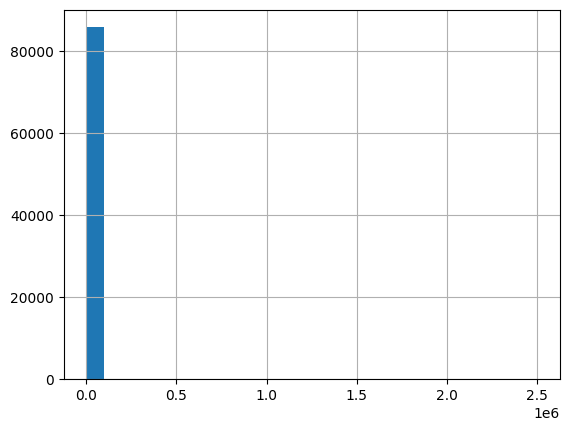

In [ ]:
df['LD50'].hist(bins=25)

<Axes: >

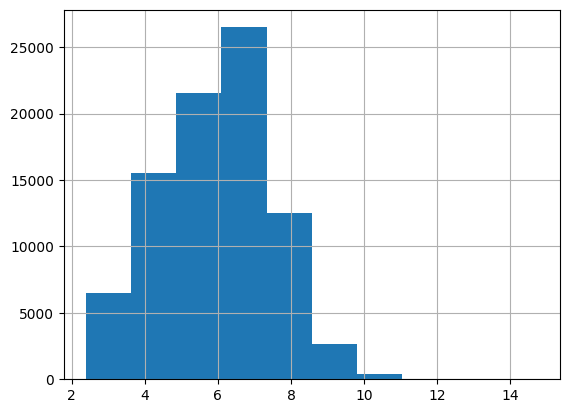

In [ ]:
df['log_LD50'].hist()

In [ ]:
X = df.drop(columns=['LD50', 'log_LD50'])
y = df['log_LD50']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=True, random_state=123)

In [ ]:
num_col = X.select_dtypes(include=['number']).columns.tolist()
cat_col = X.select_dtypes(include=['category']).columns.tolist()

X_train_cat = X_train[cat_col]
X_train_num = X_train[num_col]

X_test_cat = X_test[cat_col]
X_test_num = X_test[num_col]

In [ ]:
OHE = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop = 'first')  # handle_unknown='ignore' для новых категорий в тесте

X_train_encoded = OHE.fit_transform(X_train_cat)
X_test_encoded = OHE.transform(X_test_cat)

ohe_columns = OHE.get_feature_names_out(cat_col)
X_train_cat = pd.DataFrame(X_train_encoded, columns=ohe_columns, index=X_train.index)
X_test_cat = pd.DataFrame(X_test_encoded, columns=ohe_columns, index=X_test.index)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train[num_col])
X_test_scaled = scaler.transform(X_test[num_col])

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col, index=X_test.index)

In [ ]:
X_train = pd.concat([X_train_cat, X_train_scaled], axis=1)
X_test = pd.concat([X_test_cat, X_test_scaled], axis=1)

In [ ]:
X_train.shape

(64345, 1392)

**Беру сразу лучшую модель по итогам вышепроведенных экспериментов на всем датасете**

In [ ]:
import torch
import torch.nn as nn

class DeepRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(X_train.shape[1], 512)
        self.batchnorm1 = nn.BatchNorm1d(512)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout()
        self.fc2 = nn.Linear(512, 256)
        self.batchnorm2 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, 128)
        self.batchnorm3 = nn.BatchNorm1d(128)
        self.fc4 = nn.Linear(128, 64)
        self.batchnorm4 = nn.BatchNorm1d(64)
        self.fc5 = nn.Linear(64, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.fc1(x)
        out = self.batchnorm1(out)
        out = self.relu(out)
        out = self.dropout(out)

        out = self.fc2(out)
        out = self.batchnorm2(out)
        out = self.relu(out)
        out = self.dropout(out)

        out = self.fc3(out)
        out = self.batchnorm3(out)
        out = self.relu(out)
        out = self.dropout(out)

        out = self.fc4(out)
        out = self.batchnorm4(out)
        out = self.relu(out)

        out = self.fc5(out)
        out = torch.nn.functional.softplus(out)
        return out

In [ ]:
model_regress = DeepRegressor()
model_regress

optimizer = torch.optim.Adam(model_regress.parameters(), lr=1e-3)

train_loss_log, train_mape_log, train_r2_log, val_loss_log, val_mape_log, val_r2_log = train(
    model = model_regress,
    optimizer = optimizer,
    criterion = torch.nn.functional.mse_loss,
    n_epochs = 10,
    train_loader=train_dataloader,
    val_loader=val_dataloader
)

Epoch 0
 train loss: 4.5756, train MAPE: 1.72, train R2: -13.4542
 val loss: 1.2206, val MAPE: 1.25, val R2: 0.1450



Epoch 1
 train loss: 1.3224, train MAPE: 1.61, train R2: -0.5404
 val loss: 1.2559, val MAPE: 0.99, val R2: 0.0777



Epoch 2
 train loss: 1.1991, train MAPE: 1.49, train R2: -2.3554
 val loss: 1.1727, val MAPE: 1.01, val R2: 0.0699



Epoch 3
 train loss: 1.1248, train MAPE: 1.45, train R2: -0.6596
 val loss: 1.2813, val MAPE: 0.88, val R2: 0.0716



Epoch 4
 train loss: 1.0594, train MAPE: 1.31, train R2: 0.1017
 val loss: 1.0310, val MAPE: 1.02, val R2: 0.1883



Epoch 5
 train loss: 0.9852, train MAPE: 1.26, train R2: 0.0322
 val loss: 1.0072, val MAPE: 1.02, val R2: 0.1776



Epoch 6
 train loss: 0.9544, train MAPE: 1.19, train R2: 0.1943
 val loss: 1.0125, val MAPE: 0.99, val R2: 0.1274



Epoch 7
 train loss: 0.9110, train MAPE: 1.17, train R2: 0.1393
 val loss: 0.9510, val MAPE: 0.97, val R2: 0.2455



Epoch 8
 train loss: 0.8837, train MAPE: 1.16, train R2: -3.0158
 val loss: 0.9122, val MAPE: 1.08, val R2: 0.3159



Epoch 9
 train loss: 0.8372, train MAPE: 1.09, train R2: 0.1662
 val loss: 0.9383, val MAPE: 0.95, val R2: 0.2825



In [ ]:
loss_log, mape_log, r2_log = test(model_regress, test_dataloader)

print(f'MAPE на тесте: {mape_log}')

MAPE на тесте: 0.9652585296758583


In [ ]:
model_regress = DeepRegressor()
model_regress

DeepRegressor(
  (fc1): Linear(in_features=1392, out_features=512, bias=True)
  (batchnorm1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (batchnorm2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (batchnorm3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=128, out_features=64, bias=True)
  (batchnorm4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc5): Linear(in_features=64, out_features=1, bias=True)
)

**Введение своей адаптированной функции потерь**

In [ ]:
def mape_loss(y_pred, y_true, eps=1e-7):
    return torch.mean(torch.abs((y_true - y_pred) / (y_true + eps)))

In [ ]:
optimizer = torch.optim.Adam(model_regress.parameters(), lr=1e-3)

train_loss_log, train_mape_log, train_r2_log, val_loss_log, val_mape_log, val_r2_log = train(
    model = model_regress,
    optimizer = optimizer,
    criterion = mape_loss,
    n_epochs = 10,
    train_loader=train_dataloader,
    val_loader=val_dataloader
)

Epoch 0
 train loss: 0.2521, train MAPE: 1.54, train R2: -1.2845
 val loss: 1.7466, val MAPE: 0.98, val R2: -0.0021



Epoch 1
 train loss: 0.1668, train MAPE: 1.33, train R2: -0.2052
 val loss: 1.4644, val MAPE: 0.92, val R2: 0.0004



Epoch 2
 train loss: 0.1563, train MAPE: 1.27, train R2: -0.6701
 val loss: 1.2670, val MAPE: 1.09, val R2: 0.1539



Epoch 3
 train loss: 0.1502, train MAPE: 1.20, train R2: -0.1531
 val loss: 1.3657, val MAPE: 0.83, val R2: 0.0863



Epoch 4
 train loss: 0.1442, train MAPE: 1.14, train R2: -0.0341
 val loss: 1.3192, val MAPE: 0.84, val R2: 0.0923



Epoch 5
 train loss: 0.1407, train MAPE: 1.07, train R2: -0.0045
 val loss: 1.1925, val MAPE: 0.89, val R2: 0.2167



Epoch 6
 train loss: 0.1363, train MAPE: 1.09, train R2: 0.0640
 val loss: 1.0899, val MAPE: 0.91, val R2: 0.2023



Epoch 7
 train loss: 0.1340, train MAPE: 1.02, train R2: 0.0079
 val loss: 1.0227, val MAPE: 0.99, val R2: 0.2022



Epoch 8
 train loss: 0.1302, train MAPE: 0.97, train R2: 0.0773
 val loss: 0.9534, val MAPE: 1.06, val R2: 0.2718



Epoch 9
 train loss: 0.1271, train MAPE: 0.97, train R2: -0.1054
 val loss: 1.0259, val MAPE: 0.91, val R2: 0.1341



In [ ]:
loss_log, mape_log, r2_log = test(model_regress, test_dataloader)

print(f'MAPE на тесте: {mape_log}')

MAPE на тесте: 0.8800098689361697


In [ ]:
model_regress = SimpleRegressor()
model_regress

SimpleRegressor(
  (fc1): Linear(in_features=1392, out_features=256, bias=True)
  (batchnorm1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (batchnorm2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

In [ ]:
train_loss_log, train_mape_log, train_r2_log, val_loss_log, val_mape_log, val_r2_log = train(
    model = model_regress,
    optimizer = torch.optim.Adam(model_regress.parameters(), lr=1e-3),
    criterion=torch.nn.functional.mse_loss,
    n_epochs = 10,
    train_loader=train_dataloader,
    val_loader=val_dataloader
)

Epoch 0
 train loss: 3.8974, train MAPE: 2.75, train R2: -11.9964
 val loss: 2.2250, val MAPE: 0.82, val R2: -0.0315



Epoch 1
 train loss: 1.9864, train MAPE: 2.35, train R2: -6.0707
 val loss: 1.8049, val MAPE: 0.78, val R2: -0.0280



Epoch 2
 train loss: 1.7621, train MAPE: 1.94, train R2: -3.0588
 val loss: 1.4494, val MAPE: 0.85, val R2: 0.1274



Epoch 3
 train loss: 1.5926, train MAPE: 1.85, train R2: -2.1102
 val loss: 1.3595, val MAPE: 0.83, val R2: 0.1013



Epoch 4
 train loss: 1.4789, train MAPE: 1.68, train R2: -1.5918
 val loss: 1.0965, val MAPE: 0.95, val R2: 0.2110



Epoch 5
 train loss: 1.3773, train MAPE: 1.66, train R2: -1.2018
 val loss: 1.2497, val MAPE: 0.83, val R2: 0.1561



Epoch 6
 train loss: 1.2938, train MAPE: 1.49, train R2: -0.9632
 val loss: 0.9478, val MAPE: 1.06, val R2: 0.3034



Epoch 7
 train loss: 1.2290, train MAPE: 1.43, train R2: -34.6038
 val loss: 0.9320, val MAPE: 1.03, val R2: 0.2907



Epoch 8
 train loss: 1.1574, train MAPE: 1.35, train R2: -1.7094
 val loss: 0.9199, val MAPE: 1.05, val R2: 0.3208



Epoch 9
 train loss: 1.0989, train MAPE: 1.29, train R2: -1.4314
 val loss: 0.9653, val MAPE: 0.91, val R2: 0.2588



In [ ]:
loss_log, mape_log, r2_log = test(model_regress, test_dataloader)

print(f'MAPE на тесте: {mape_log}')

MAPE на тесте: 0.8902322853959742


Метрика стала лучше, значит в целом модель можно доработать до лучших показателей для предсказания высоких показателей токсичности